### 08 — Project 1 Error Analysis

### Intelligent CFPB Product Classification

### Objective

- Understand where and why the final validation model fails.

- This notebook analyzes:

1. Overall correct vs incorrect predictions
2. Per-class performance
3. False positives and false negatives
4. Confusion pairs
5. High-confidence errors
6. Low-confidence predictions
7. Representative narrative errors
8. Company-related behavior
9. Error concentration by class
10. Model limitations and readiness for final test evaluation

### Frozen model

- Features: Consumer complaint narrative + Company
- Word TF-IDF: `(1,2)`
- Character TF-IDF: `(3,5)`
- Company: One-hot encoding
- Model: Logistic Regression
- `C = 1.0`
- `class_weight = None`

### Primary metric:- Macro F1

### Important:- The test set is NOT loaded or evaluated in this notebook.

In [1]:
## Importing
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
## Paths
PROJECT_ROOT = Path("..")

TRAIN_PATH = (
    PROJECT_ROOT
    / "Data"
    / "processed"
    / "project1_train.csv"
)

VAL_PATH = (
    PROJECT_ROOT
    / "Data"
    / "processed"
    / "project1_validation.csv"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "Reports"
    / "project1"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Reports:", REPORT_DIR)

Train: ..\Data\processed\project1_train.csv
Validation: ..\Data\processed\project1_validation.csv
Reports: ..\Reports\project1


In [3]:
### Load Train and Validation
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (58422, 18)
Validation shape: (11685, 18)


In [4]:
## Define Columns
TEXT_COL = "Consumer complaint narrative"
COMPANY_COL = "Company"
TARGET_COL = "Product"

ID_COL = "Complaint ID"

required_columns = [
    TEXT_COL,
    COMPANY_COL,
    TARGET_COL,
]

for column in required_columns:
    assert column in train_df.columns
    assert column in val_df.columns

print("Required columns: PASS")

Required columns: PASS


In [5]:
## Preparing Data
X_train_text = (
    train_df[TEXT_COL]
    .fillna("")
    .astype(str)
)

X_val_text = (
    val_df[TEXT_COL]
    .fillna("")
    .astype(str)
)

X_train_company = (
    train_df[[COMPANY_COL]]
    .fillna("MISSING")
    .astype(str)
)

X_val_company = (
    val_df[[COMPANY_COL]]
    .fillna("MISSING")
    .astype(str)
)

y_train = train_df[TARGET_COL].astype(str)
y_val = val_df[TARGET_COL].astype(str)

print("Training rows:", len(y_train))
print("Validation rows:", len(y_val))
print("Classes:", y_train.nunique())

Training rows: 58422
Validation rows: 11685
Classes: 11


In [6]:
### Rebuild Build the Frozen feature Pipeline
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000,
    sublinear_tf=True,
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=10000,
    sublinear_tf=True,
)

company_encoder = OneHotEncoder(
    handle_unknown="ignore",
)

X_train_word = word_vectorizer.fit_transform(
    X_train_text
)

X_val_word = word_vectorizer.transform(
    X_val_text
)

X_train_char = char_vectorizer.fit_transform(
    X_train_text
)

X_val_char = char_vectorizer.transform(
    X_val_text
)

X_train_company = company_encoder.fit_transform(
    X_train_company
)

X_val_company = company_encoder.transform(
    X_val_company
)

X_train = hstack([
    X_train_word,
    X_train_char,
    X_train_company,
]).tocsr()

X_val = hstack([
    X_val_word,
    X_val_char,
    X_val_company,
]).tocsr()

print("Word:", X_train_word.shape)
print("Character:", X_train_char.shape)
print("Company:", X_train_company.shape)
print("Combined:", X_train.shape)

Word: (58422, 10000)
Character: (58422, 10000)
Company: (58422, 1751)
Combined: (58422, 21751)


In [9]:
### Train the Frogen candidate model
model = LogisticRegression(
    C=1.0,
    class_weight=None,
    max_iter=2000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

model.fit(
    X_train,
    y_train,
)

print("Frozen candidate model trained.")

Frozen candidate model trained.


In [10]:
### Generate Validation Prediction
val_predictions = model.predict(X_val)

val_probabilities = model.predict_proba(X_val)

classes = model.classes_

print("Predictions generated.")
print("Prediction count:", len(val_predictions))
print("Probability shape:", val_probabilities.shape)

Predictions generated.
Prediction count: 11685
Probability shape: (11685, 11)


In [14]:
## Create Data Analysis Dataframe
analysis_df = val_df.copy()

analysis_df["Actual_Product"] = y_val.values
analysis_df["Predicted_Product"] = val_predictions

analysis_df["Correct"] = (
    analysis_df["Actual_Product"]
    == analysis_df["Predicted_Product"]
)

analysis_df["Prediction_Confidence"] = (
    val_probabilities.max(axis=1)
)

# analysis_df["Prediction_Confidence_Rank"] = (
#     np.argsort(
#         -val_probabilities,
#         axis=1
#     )[:, :3]
# )

# Get top-3 predicted class indices
top3_indices = np.argsort(
    -val_probabilities,
    axis=1
)[:, :3]

analysis_df["Prediction_Rank_1"] = top3_indices[:, 0]
analysis_df["Prediction_Rank_2"] = top3_indices[:, 1]
analysis_df["Prediction_Rank_3"] = top3_indices[:, 2]

# Select only required columns
analysis_selected_df = analysis_df[
    [
        "Actual_Product",
        "Predicted_Product",
        "Correct",
        "Prediction_Confidence",
        "Prediction_Rank_1",
        "Prediction_Rank_2",
        "Prediction_Rank_3",
    ]
].copy()

print("Selected analysis dataframe:", analysis_selected_df.shape)

analysis_selected_df.head()


Selected analysis dataframe: (11685, 7)


,Actual_Product,Predicted_Product,Correct,Prediction_Confidence,Prediction_Rank_1,Prediction_Rank_2,Prediction_Rank_3
0,Debt collection,Debt collection,True,0.988565,3,10,4
1,Credit card,Checking or savings account,False,0.732924,0,5,8
2,Debt collection,Debt collection,True,0.987232,3,1,7
3,Credit card,Credit card,True,0.950813,1,10,0
4,Checking or savings account,Checking or savings account,True,0.863703,0,1,5


In [15]:
## Overall Validation Error Analysis Summary
total = len(analysis_df)

correct = analysis_df["Correct"].sum()
incorrect = total - correct

accuracy = correct / total

print("====================================")
print("VALIDATION ERROR SUMMARY")
print("====================================")

print(f"Total predictions : {total:,}")
print(f"Correct           : {correct:,}")
print(f"Incorrect         : {incorrect:,}")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Error rate        : {1 - accuracy:.4f}")

VALIDATION ERROR SUMMARY
Total predictions : 11,685
Correct           : 10,143
Incorrect         : 1,542
Accuracy          : 0.8680
Error rate        : 0.1320


In [16]:
## Correct VS Incorrect distribution
correct_counts = (
    analysis_df["Correct"]
    .value_counts()
    .rename(index={
        True: "Correct",
        False: "Incorrect",
    })
)

correct_counts

Correct
Correct      10143
Incorrect     1542
Name: count, dtype: int64

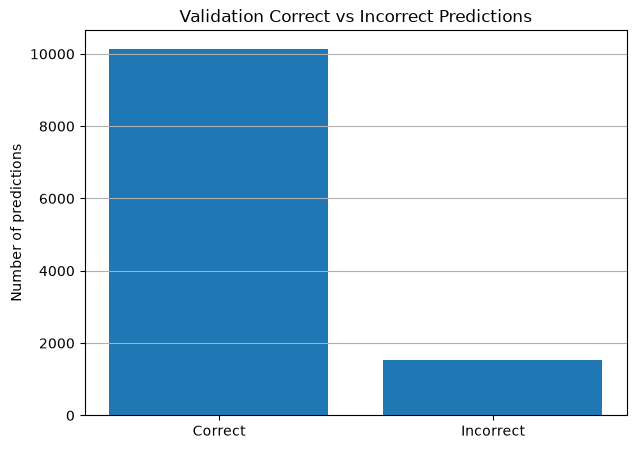

In [17]:
## Visualization Errors
plt.figure(figsize=(7, 5))

plt.bar(
    correct_counts.index,
    correct_counts.values,
)

plt.ylabel("Number of predictions")
plt.title("Validation Correct vs Incorrect Predictions")

plt.grid(axis="y")

plt.show()

In [18]:
## Per-Class Error Analysis
class_report = classification_report(
    y_val,
    val_predictions,
    output_dict=True,
    zero_division=0,
)

class_metrics = []

for product in classes:
    class_metrics.append({
        "Product": product,
        "Precision": class_report[product]["precision"],
        "Recall": class_report[product]["recall"],
        "F1": class_report[product]["f1-score"],
        "Support": int(class_report[product]["support"]),
    })

class_metrics_df = pd.DataFrame(class_metrics)

class_metrics_df.sort_values(
    "F1"
)

,Product,Precision,Recall,F1,Support
4,Debt or credit management,0.925000,0.359223,0.517483,103
8,Prepaid card,0.808989,0.553846,0.657534,130
7,"Payday loan, title loan, personal loan, or adv...",0.748619,0.657767,0.700258,412
5,"Money transfer, virtual currency, or money ser...",0.770686,0.697326,0.732173,935
0,Checking or savings account,0.796848,0.868321,0.831050,2096
2,Credit reporting or other personal consumer re...,0.827381,0.874214,0.850153,477
1,Credit card,0.855210,0.866497,0.860817,1970
10,Vehicle loan or lease,0.888268,0.839789,0.863348,568
3,Debt collection,0.926955,0.936590,0.931748,3848
6,Mortgage,0.952381,0.944882,0.948617,762


In [19]:
## Add Error Counts
error_counts = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .groupby("Actual_Product")
    .size()
    .reset_index(name="Errors")
    .rename(
        columns={
            "Actual_Product": "Product"
        }
    )
)

class_metrics_df = class_metrics_df.merge(
    error_counts,
    on="Product",
    how="left",
)

class_metrics_df["Errors"] = (
    class_metrics_df["Errors"]
    .fillna(0)
    .astype(int)
)

class_metrics_df["Error_Rate"] = (
    class_metrics_df["Errors"]
    / class_metrics_df["Support"]
)

class_metrics_df.sort_values(
    "Error_Rate",
    ascending=False,
)

,Product,Precision,Recall,F1,Support,Errors,Error_Rate
4,Debt or credit management,0.925000,0.359223,0.517483,103,66,0.640777
8,Prepaid card,0.808989,0.553846,0.657534,130,58,0.446154
7,"Payday loan, title loan, personal loan, or adv...",0.748619,0.657767,0.700258,412,141,0.342233
5,"Money transfer, virtual currency, or money ser...",0.770686,0.697326,0.732173,935,283,0.302674
10,Vehicle loan or lease,0.888268,0.839789,0.863348,568,91,0.160211
1,Credit card,0.855210,0.866497,0.860817,1970,263,0.133503
0,Checking or savings account,0.796848,0.868321,0.831050,2096,276,0.131679
2,Credit reporting or other personal consumer re...,0.827381,0.874214,0.850153,477,60,0.125786
3,Debt collection,0.926955,0.936590,0.931748,3848,244,0.063410
6,Mortgage,0.952381,0.944882,0.948617,762,42,0.055118


In [20]:
## Identify Difficult Classes
difficult_classes = class_metrics_df.sort_values(
    "F1"
)

difficult_classes[
    [
        "Product",
        "Support",
        "Precision",
        "Recall",
        "F1",
        "Errors",
        "Error_Rate",
    ]
]

,Product,Support,Precision,Recall,F1,Errors,Error_Rate
4,Debt or credit management,103,0.925000,0.359223,0.517483,66,0.640777
8,Prepaid card,130,0.808989,0.553846,0.657534,58,0.446154
7,"Payday loan, title loan, personal loan, or adv...",412,0.748619,0.657767,0.700258,141,0.342233
5,"Money transfer, virtual currency, or money ser...",935,0.770686,0.697326,0.732173,283,0.302674
0,Checking or savings account,2096,0.796848,0.868321,0.831050,276,0.131679
2,Credit reporting or other personal consumer re...,477,0.827381,0.874214,0.850153,60,0.125786
1,Credit card,1970,0.855210,0.866497,0.860817,263,0.133503
10,Vehicle loan or lease,568,0.888268,0.839789,0.863348,91,0.160211
3,Debt collection,3848,0.926955,0.936590,0.931748,244,0.063410
6,Mortgage,762,0.952381,0.944882,0.948617,42,0.055118


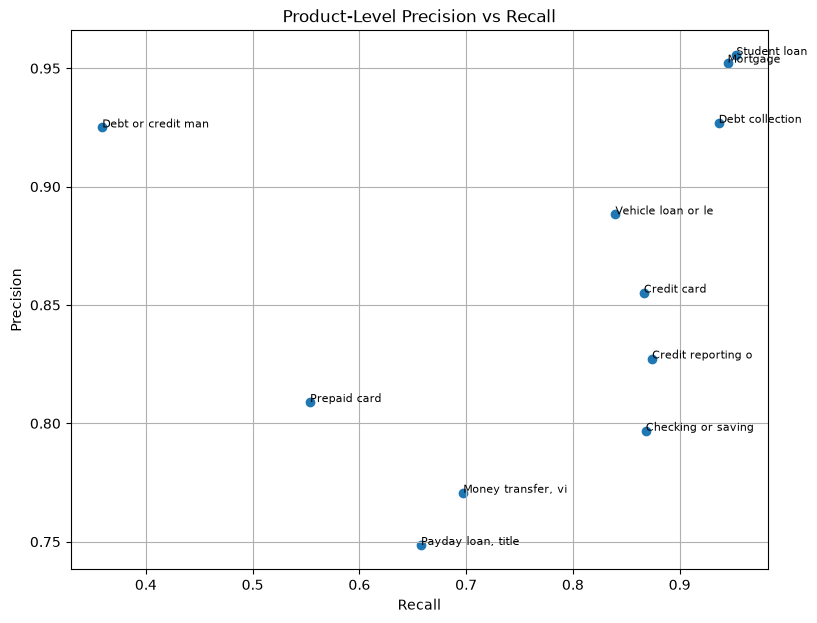

In [21]:
## Important Diagnostic: Precision vs Recall
plt.figure(figsize=(9, 7))

plt.scatter(
    class_metrics_df["Recall"],
    class_metrics_df["Precision"],
)

for _, row in class_metrics_df.iterrows():
    plt.annotate(
        row["Product"][:18],
        (
            row["Recall"],
            row["Precision"],
        ),
        fontsize=8,
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Product-Level Precision vs Recall")

plt.grid(True)

plt.show()

In [22]:
## Find high false-negative classes
low_recall = class_metrics_df.sort_values(
    "Recall"
)

low_recall[
    [
        "Product",
        "Support",
        "Precision",
        "Recall",
        "F1",
    ]
].head(5)

,Product,Support,Precision,Recall,F1
4,Debt or credit management,103,0.925000,0.359223,0.517483
8,Prepaid card,130,0.808989,0.553846,0.657534
7,"Payday loan, title loan, personal loan, or adv...",412,0.748619,0.657767,0.700258
5,"Money transfer, virtual currency, or money ser...",935,0.770686,0.697326,0.732173
10,Vehicle loan or lease,568,0.888268,0.839789,0.863348


In [23]:
## Find Low-Precision classes
low_precision = class_metrics_df.sort_values(
    "Precision"
)

low_precision[
    [
        "Product",
        "Support",
        "Precision",
        "Recall",
        "F1",
    ]
].head(5)

,Product,Support,Precision,Recall,F1
7,"Payday loan, title loan, personal loan, or adv...",412,0.748619,0.657767,0.700258
5,"Money transfer, virtual currency, or money ser...",935,0.770686,0.697326,0.732173
0,Checking or savings account,2096,0.796848,0.868321,0.831050
8,Prepaid card,130,0.808989,0.553846,0.657534
2,Credit reporting or other personal consumer re...,477,0.827381,0.874214,0.850153


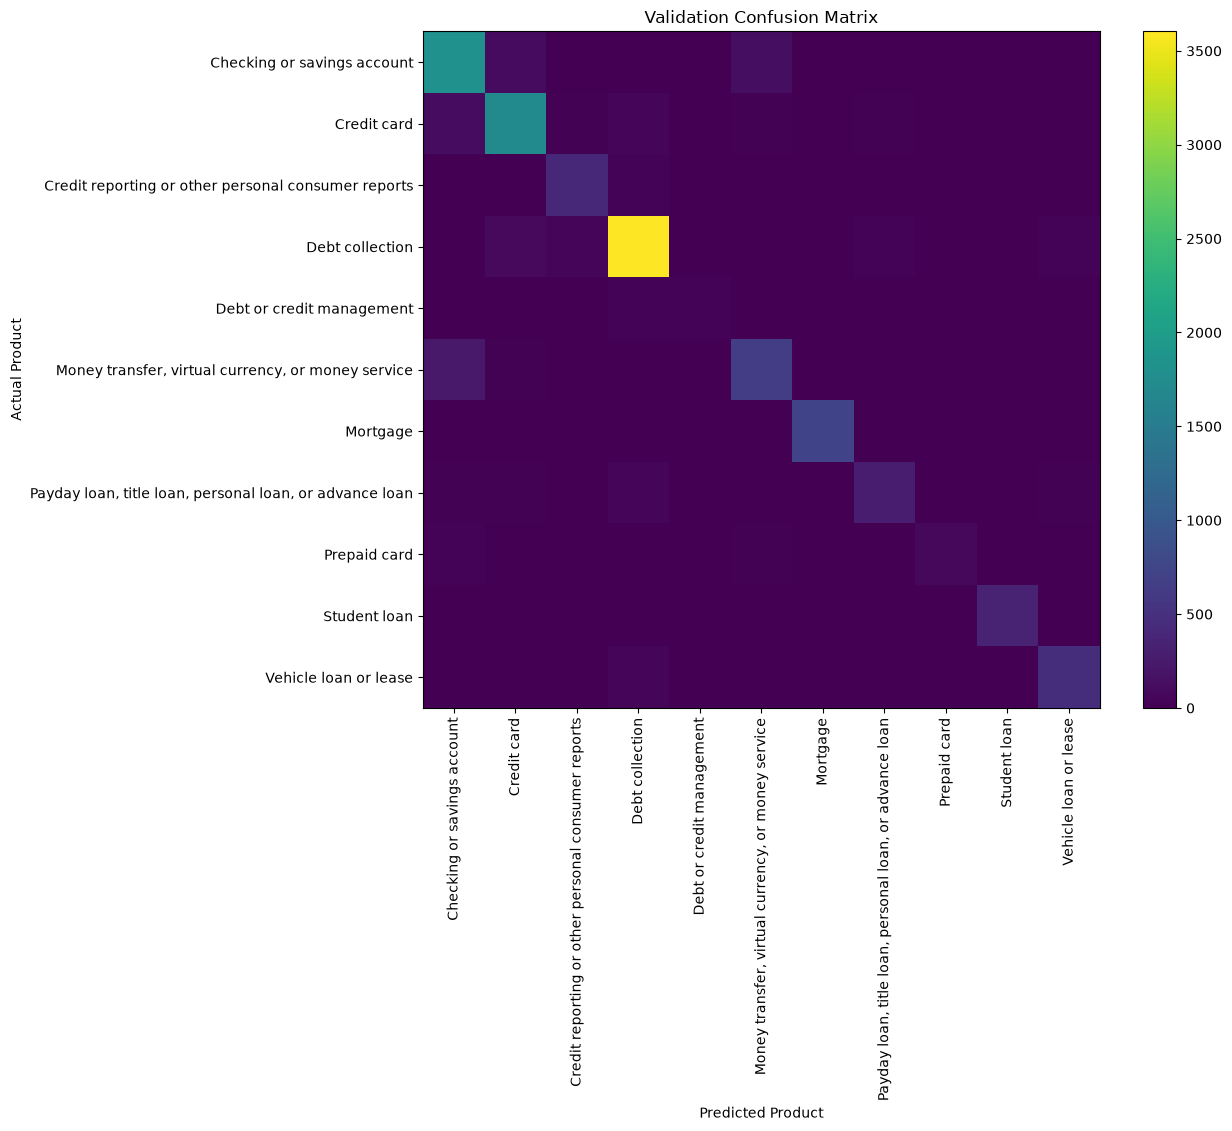

In [24]:
### Confusion Matrix
cm = confusion_matrix(
    y_val,
    val_predictions,
    labels=classes,
)

plt.figure(figsize=(13, 11))

plt.imshow(cm)

plt.xticks(
    range(len(classes)),
    classes,
    rotation=90,
)

plt.yticks(
    range(len(classes)),
    classes,
)

plt.xlabel("Predicted Product")
plt.ylabel("Actual Product")
plt.title("Validation Confusion Matrix")

plt.colorbar()

plt.tight_layout()

plt.show()

In [25]:
### Ranked Confusion Pairs
confusion_pairs = []

for i, actual in enumerate(classes):
    for j, predicted in enumerate(classes):

        if actual == predicted:
            continue

        count = cm[i, j]

        if count > 0:
            confusion_pairs.append({
                "Actual": actual,
                "Predicted": predicted,
                "Count": count,
            })

confusion_pairs_df = (
    pd.DataFrame(confusion_pairs)
    .sort_values(
        "Count",
        ascending=False,
    )
)

confusion_pairs_df.head(20)

,Actual,Predicted,Count
41,"Money transfer, virtual currency, or money ser...",Checking or savings account,242
3,Checking or savings account,"Money transfer, virtual currency, or money ser...",132
8,Credit card,Checking or savings account,124
0,Checking or savings account,Credit card,104
25,Debt collection,Credit card,92
10,Credit card,Debt collection,65
57,"Payday loan, title loan, personal loan, or adv...",Debt collection,56
26,Debt collection,Credit reporting or other personal consumer re...,51
76,Vehicle loan or lease,Debt collection,46
19,Credit reporting or other personal consumer re...,Debt collection,42


### Confusion Concentration
- This is an important insight.
- If a relatively small number of confusion pairs explain a large percentage of errors, the problem is structured, not random.

In [26]:
## Confusion Concentration
top_10_confusions = (
    confusion_pairs_df
    .head(10)["Count"]
    .sum()
)

total_errors = (
    ~analysis_df["Correct"]
).sum()

print(
    f"Top 10 confusion pairs account for "
    f"{top_10_confusions:,} of {total_errors:,} errors."
)

print(
    f"Share of all errors: "
    f"{top_10_confusions / total_errors:.2%}"
)

Top 10 confusion pairs account for 954 of 1,542 errors.
Share of all errors: 61.87%


In [27]:
## Focus on the major confusion Pairs
TOP_CONFUSION_PAIRS = 10

top_pairs = confusion_pairs_df.head(
    TOP_CONFUSION_PAIRS
)

top_pairs

,Actual,Predicted,Count
41,"Money transfer, virtual currency, or money ser...",Checking or savings account,242
3,Checking or savings account,"Money transfer, virtual currency, or money ser...",132
8,Credit card,Checking or savings account,124
0,Checking or savings account,Credit card,104
25,Debt collection,Credit card,92
10,Credit card,Debt collection,65
57,"Payday loan, title loan, personal loan, or adv...",Debt collection,56
26,Debt collection,Credit reporting or other personal consumer re...,51
76,Vehicle loan or lease,Debt collection,46
19,Credit reporting or other personal consumer re...,Debt collection,42


In [28]:
## exact False-negative/False-possitive View
analysis_df["Is_False_Positive_For_Prediction"] = (
    ~analysis_df["Correct"]
)

analysis_df["Is_False_Negative_For_Actual"] = (
    ~analysis_df["Correct"]
)

print("False-positive/error rows:", (~analysis_df["Correct"]).sum())
print("False-negative/error rows:", (~analysis_df["Correct"]).sum())

False-positive/error rows: 1542
False-negative/error rows: 1542


In [29]:
## False-negatives by actual class
false_negative_counts = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .groupby("Actual_Product")
    .size()
    .sort_values(
        ascending=False
    )
)

false_negative_counts

Actual_Product
Money transfer, virtual currency, or money service         283
Checking or savings account                                276
Credit card                                                263
Debt collection                                            244
Payday loan, title loan, personal loan, or advance loan    141
Vehicle loan or lease                                       91
Debt or credit management                                   66
Credit reporting or other personal consumer reports         60
Prepaid card                                                58
Mortgage                                                    42
Student loan                                                18
dtype: int64

In [30]:
## False-possitives by actual class
false_positive_counts = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .groupby("Predicted_Product")
    .size()
    .sort_values(
        ascending=False
    )
)

false_positive_counts

Predicted_Product
Checking or savings account                                464
Credit card                                                289
Debt collection                                            284
Money transfer, virtual currency, or money service         194
Payday loan, title loan, personal loan, or advance loan     91
Credit reporting or other personal consumer reports         87
Vehicle loan or lease                                       60
Mortgage                                                    36
Prepaid card                                                17
Student loan                                                17
Debt or credit management                                    3
dtype: int64

In [31]:
## False-possitives by predicted class
false_positive_counts = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .groupby("Predicted_Product")
    .size()
    .sort_values(
        ascending=False
    )
)

false_positive_counts

Predicted_Product
Checking or savings account                                464
Credit card                                                289
Debt collection                                            284
Money transfer, virtual currency, or money service         194
Payday loan, title loan, personal loan, or advance loan     91
Credit reporting or other personal consumer reports         87
Vehicle loan or lease                                       60
Mortgage                                                    36
Prepaid card                                                17
Student loan                                                17
Debt or credit management                                    3
dtype: int64

In [32]:
## Prediction confidence
confidence_summary = (
    analysis_df["Prediction_Confidence"]
    .describe()
)

confidence_summary

count    11685.000000
mean         0.850014
std          0.176739
min          0.198108
25%          0.760446
50%          0.932350
75%          0.987466
max          0.999892
Name: Prediction_Confidence, dtype: float64

In [33]:
## confidence: correct vs incorrect
analysis_df.groupby(
    "Correct"
)["Prediction_Confidence"].agg(
    [
        "count",
        "mean",
        "median",
        "min",
        "max",
    ]
)

,count,mean,median,min,max
Correct,,,,,
False,1542,0.638255,0.617653,0.223824,0.996896
True,10143,0.882207,0.951400,0.198108,0.999892


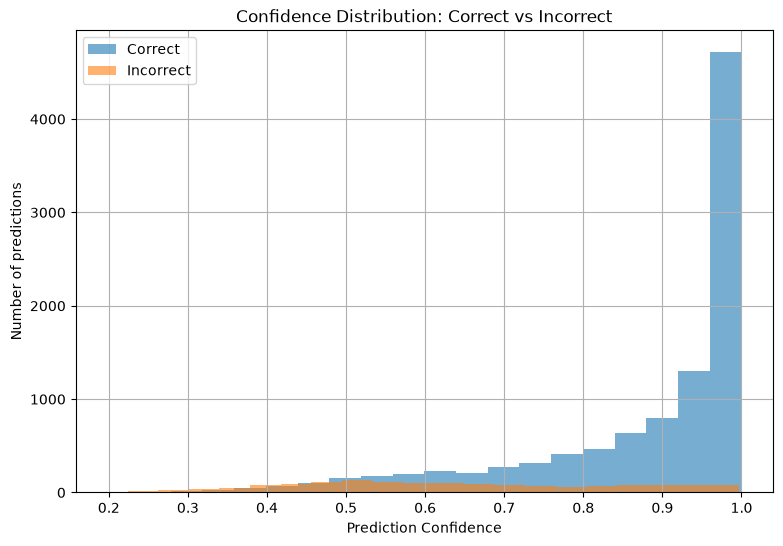

In [34]:
## confidence Distribusions
plt.figure(figsize=(9, 6))

plt.hist(
    analysis_df.loc[
        analysis_df["Correct"],
        "Prediction_Confidence"
    ],
    bins=20,
    alpha=0.6,
    label="Correct",
)

plt.hist(
    analysis_df.loc[
        ~analysis_df["Correct"],
        "Prediction_Confidence"
    ],
    bins=20,
    alpha=0.6,
    label="Incorrect",
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of predictions")
plt.title("Confidence Distribution: Correct vs Incorrect")

plt.legend()
plt.grid(True)

plt.show()

In [35]:
## High-Confidence wrong predictions
high_confidence_errors = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .sort_values(
        "Prediction_Confidence",
        ascending=False,
    )
)

high_confidence_errors[
    [
        ID_COL,
        "Actual_Product",
        "Predicted_Product",
        "Prediction_Confidence",
        TEXT_COL,
        COMPANY_COL,
    ]
].head(20)

,Complaint ID,Actual_Product,Predicted_Product,Prediction_Confidence,Consumer complaint narrative,Company
10271,22614178,Credit card,Debt collection,0.996896,I have reasons to believe that the debt collec...,"CAVALRY INVESTMENTS, LLC"
1383,22754012,Debt or credit management,Debt collection,0.996678,XXXX XXXX XXXX ] [ XXXX XXXX XXXX XXXX [ XXXX ...,CL Holdings LLC
3340,20047217,Credit card,Debt collection,0.996631,15 65c 1692 ( c ) c That law clearly states th...,"Bread Financial Holdings, Inc."
3555,20180444,Credit reporting or other personal consumer re...,Debt collection,0.996168,"Dear Consumer Financial Protection Bureau, I f...",Central Portfolio Control Inc.
1068,20015827,Credit reporting or other personal consumer re...,Debt collection,0.995935,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX, ...","Aargon Agency, Inc."
8141,21383782,Debt collection,Credit card,0.995615,While being a customer of bank of America i ha...,"BANK OF AMERICA, NATIONAL ASSOCIATION"
6948,20701263,Credit card,Debt collection,0.995610,I am submitting this complaint regarding a col...,"I.C. System, Inc."
8920,21946666,Debt collection,Credit card,0.994769,"I received a summons, handed to me, now I have...","CLGF Holdco 1, LLC"
4609,21174544,Credit card,Debt collection,0.994411,Please verify this account. I am requesting va...,TrueAccord Corp.
8229,21444366,Debt collection,Mortgage,0.994028,This is by 2nd time filing a complaint on the ...,"Rocket Mortgage, LLC"


In [36]:
## Low-confidence correct prediction
low_confidence_correct = (
    analysis_df[
        analysis_df["Correct"]
    ]
    .sort_values(
        "Prediction_Confidence"
    )
)

low_confidence_correct[
    [
        ID_COL,
        "Actual_Product",
        "Predicted_Product",
        "Prediction_Confidence",
        TEXT_COL,
        COMPANY_COL,
    ]
].head(20)

,Complaint ID,Actual_Product,Predicted_Product,Prediction_Confidence,Consumer complaint narrative,Company
3088,20117977,Vehicle loan or lease,Vehicle loan or lease,0.198108,Bank of America is showing a loan on my accoun...,"BANK OF AMERICA, NATIONAL ASSOCIATION"
6293,22403070,Mortgage,Mortgage,0.232193,"I receive letters similar to the attached, som...",United Mortgage Lending LLC
3657,20296854,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...",0.258611,CheckbookXXXX is currently withholding two se...,Checkbook Inc
1789,21003279,"Payday loan, title loan, personal loan, or adv...","Payday loan, title loan, personal loan, or adv...",0.262221,We first met with the XXXX from XXXX XXXX in X...,TRUIST FINANCIAL CORPORATION
9943,23004230,"Payday loan, title loan, personal loan, or adv...","Payday loan, title loan, personal loan, or adv...",0.267671,"In XXXX XXXX, a representative named XXXX XXXX...",Premlo Inc.
2096,23910449,"Payday loan, title loan, personal loan, or adv...","Payday loan, title loan, personal loan, or adv...",0.269253,I was taking out a loan with them around XXXX ...,"Tribal Lending Enterprise, Inc."
6129,20280269,Vehicle loan or lease,Vehicle loan or lease,0.283879,Complaint Against : Fifth Third Bank Product :...,FIFTH THIRD FINANCIAL CORPORATION
5296,21685611,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...",0.286615,"Our company name is XXXX XXXX XXXX, locate in ...",FISERV FINXACT CORE
9044,22083719,Student loan,Student loan,0.296458,"In early XXXX XXXX, I refinanced a student lo...","SOFI TECHNOLOGIES, INC."
1251,20208169,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...",0.302826,"On XX/XX/year>, a hotel stay at XXXX by XXXX X...","Block, Inc."


In [37]:
## Low confidence errors
low_confidence_errors = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .sort_values(
        "Prediction_Confidence"
    )
)

low_confidence_errors[
    [
        ID_COL,
        "Actual_Product",
        "Predicted_Product",
        "Prediction_Confidence",
        TEXT_COL,
        COMPANY_COL,
    ]
].head(20)

,Complaint ID,Actual_Product,Predicted_Product,Prediction_Confidence,Consumer complaint narrative,Company
11007,22653084,"Payday loan, title loan, personal loan, or adv...",Debt or credit management,0.223824,Brigit keeps charging subscription fees even a...,"Bridge IT, Inc."
10766,22977611,Debt or credit management,Checking or savings account,0.229866,I checked my account and noticed the credit sc...,Kovo
4486,21288758,Checking or savings account,Debt collection,0.233429,I intended to purchase only XXXX. XXXX XXXX of...,FISERV FINXACT CORE
1221,20164743,Debt or credit management,Debt collection,0.236004,XXXX contacted XXXX regarding debtor XXXX XXXX...,HF Holdings
10740,23986203,Mortgage,Checking or savings account,0.237142,I am the borrower on a USAA home equity line o...,UNITED SERVICES AUTOMOBILE ASSOCIATION
171,21389415,Credit card,"Payday loan, title loan, personal loan, or adv...",0.240585,I previously registered a complaint for Servic...,"Servicing Solutions, LLC"
5952,19950530,Debt collection,Mortgage,0.246323,I am submitting this feedback in response to t...,"FirstKey Holdings, LLC"
10714,24213666,"Payday loan, title loan, personal loan, or adv...",Mortgage,0.256034,I am a XXXXXXXX XXXX XXXX XXXX XXXX XXXX XXXX ...,TRUIST FINANCIAL CORPORATION
3835,20759448,"Payday loan, title loan, personal loan, or adv...",Mortgage,0.256175,On XX/XX/XXXX I entered into a XXXX interest-f...,TRUIST FINANCIAL CORPORATION
5064,21733321,"Payday loan, title loan, personal loan, or adv...",Mortgage,0.256881,* * * This is the description I included in a ...,TRUIST FINANCIAL CORPORATION


In [38]:
### High-confidence errors by confusion pair 
high_conf_pair_summary = (
    high_confidence_errors
    .groupby(
        [
            "Actual_Product",
            "Predicted_Product",
        ]
    )
    .agg(
        Errors=("Correct", "size"),
        Mean_Confidence=(
            "Prediction_Confidence",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        "Errors",
        ascending=False,
    )
)

high_conf_pair_summary.head(15)

,Actual_Product,Predicted_Product,Errors,Mean_Confidence
41,"Money transfer, virtual currency, or money ser...",Checking or savings account,242,0.698806
3,Checking or savings account,"Money transfer, virtual currency, or money ser...",132,0.672813
8,Credit card,Checking or savings account,124,0.602797
0,Checking or savings account,Credit card,104,0.612620
25,Debt collection,Credit card,92,0.718700
10,Credit card,Debt collection,65,0.679322
57,"Payday loan, title loan, personal loan, or adv...",Debt collection,56,0.659271
26,Debt collection,Credit reporting or other personal consumer re...,51,0.591166
76,Vehicle loan or lease,Debt collection,46,0.648018
19,Credit reporting or other personal consumer re...,Debt collection,42,0.668717


In [39]:
## Inspect representive examples
def show_examples(
    actual,
    predicted,
    n=5,
):
    subset = analysis_df[
        (analysis_df["Actual_Product"] == actual)
        &
        (analysis_df["Predicted_Product"] == predicted)
    ].copy()

    subset = subset.sort_values(
        "Prediction_Confidence",
        ascending=False,
    )

    columns = [
        ID_COL,
        COMPANY_COL,
        "Prediction_Confidence",
        TEXT_COL,
    ]

    return subset[columns].head(n)

In [40]:
## Inspect major confusion: Money transfer → Checking
show_examples(
    actual="Money transfer, virtual currency, or money service",
    predicted="Checking or savings account",
    n=10,
)

,Complaint ID,Company,Prediction_Confidence,Consumer complaint narrative
2154,23253209,CAPITAL ONE FINANCIAL CORPORATION,0.990065,I opened a checking account with Capital One a...
1733,20888606,Chime Financial Inc,0.989935,My account was closed do to fraud activity the...
7278,20551375,JPMORGAN CHASE & CO.,0.989313,I am filing a complaint regarding my banks han...
9189,22219013,"HUNTINGTON NATIONAL BANK, THE",0.981826,"I visited Huntington Bank ( XXXX, XXXX ) [ XX..."
883,22770471,JPMORGAN CHASE & CO.,0.981525,On XX/XX/year>2026 I made XXXX mobile deposits...
6488,20182035,FIFTH THIRD FINANCIAL CORPORATION,0.978712,I am filing this complaint against Fifth Third...
6960,20401300,REGIONS FINANCIAL CORPORATION,0.972705,On XX/XX/XXXX I changed my son 's & I bank dep...
9333,24367501,WELLS FARGO & COMPANY,0.970928,I am submitting this complaint regarding Wells...
7205,20834651,"CITIBANK, N.A.",0.969501,I am filing this complaint regarding a failure...
10620,23315129,"BANK OF AMERICA, NATIONAL ASSOCIATION",0.969500,"Between XX/XX/XXXX and XX/XX/scrub>, 2026, I r..."


In [41]:
## Inspect major confusion: Checking → Money transfer
show_examples(
    actual="Checking or savings account",
    predicted="Money transfer, virtual currency, or money service",
    n=10,
)

,Complaint ID,Company,Prediction_Confidence,Consumer complaint narrative
5479,19981279,"Block, Inc.",0.982250,I am filing this complaint regarding a fraud i...
2117,22976289,"Paypal Holdings, Inc",0.954481,Someone got unauthorized access to my home com...
11452,23719614,"Paypal Holdings, Inc",0.948621,I am submitting this statement to formally dis...
1747,20962152,"Block, Inc.",0.944762,I am submitting this formal complaint regardin...
10613,22084379,"Block, Inc.",0.939616,I am submitting this complaint to request assi...
5497,19996568,"Paypal Holdings, Inc",0.934705,have maintained a PayPal account for approxima...
368,21675177,"Early Warning Services, LLC",0.931218,"On Monday XX/XX/XXXX, I was contacted by an in..."
7430,20969050,"Paypal Holdings, Inc",0.927433,"To Whom It May Concern, I am submitting this f..."
9357,22106821,"Block, Inc.",0.926582,"On XX/XX/2026, I was contacted by a person cla..."
11665,23809288,"Block, Inc.",0.925550,"On XX/XX/year>, at approximately XXXX XXXX, I ..."


In [42]:
### Inspect Credit card → Checking
show_examples(
    actual="Credit card",
    predicted="Checking or savings account",
    n=10,
)

,Complaint ID,Company,Prediction_Confidence,Consumer complaint narrative
6046,19992752,Chime Financial Inc,0.970102,"To Whom It May Concern, I am writing to formal..."
3926,20819075,Chime Financial Inc,0.965719,"From XX/XX/2026 to XX/XX/2026, Ive had over {$..."
4463,21278049,FinCo Services Inc DBA Current,0.936035,Name : XXXX XXXX XXXX Email used with Current ...
10560,23787836,Chime Financial Inc,0.931134,I no longer have the account but I made a disp...
6095,20015840,"SOFI TECHNOLOGIES, INC.",0.926785,I got with a bank that provides a debit as wel...
2308,22986807,Chime Financial Inc,0.912430,The chime company is not given back the money ...
5631,21887083,NAVY FEDERAL CREDIT UNION,0.907376,I am filing a complaint against Navy Federal C...
4130,21022626,"BANK OF AMERICA, NATIONAL ASSOCIATION",0.870951,Regarding Bank of America accounts ending in #...
10135,22542645,"SOFI TECHNOLOGIES, INC.",0.868788,I am filing my XXXX CFPB complaint against So...
1399,23077759,U.S. BANCORP,0.865564,I ORDERED FOOD FROM XXXX XXXX XXXX IN XX/XX/y...


In [43]:
## Inspect Checking → Credit card
show_examples(
    actual="Checking or savings account",
    predicted="Credit card",
    n=10,
)

,Complaint ID,Company,Prediction_Confidence,Consumer complaint narrative
3653,20294388,NAVY FEDERAL CREDIT UNION,0.986377,Credit card misused and checking account being...
5524,20020447,"BANK OF AMERICA, NATIONAL ASSOCIATION",0.977903,I am submitting this complaint regarding late ...
9078,22122178,AMERICAN EXPRESS COMPANY,0.926008,"Statement of Fact : On XX/XX/year>, at XXXX XX..."
9764,23462276,SYNCHRONY FINANCIAL,0.922838,I am filing this complaint against Synchrony B...
4036,20970364,CAPITAL ONE FINANCIAL CORPORATION,0.922723,RE : COMPLAINT AGAINST CAPITAL ONE FAILURE TO ...
11498,22794522,"BANK OF AMERICA, NATIONAL ASSOCIATION",0.901677,"My last BOA statement for XXXX, XXXX indicated..."
1896,21165023,CAPITAL ONE FINANCIAL CORPORATION,0.898402,"On XX/XX/XXXX, I mailed a {$500.00} XXXX money..."
7458,23664537,GOLDMAN SACHS BANK USA,0.898047,"On XX/XX/XXXX, I tried to purchase transportat..."
3968,20859070,U.S. BANCORP,0.893649,Received an alert from my credit management ( ...
2247,23318741,CAPITAL ONE FINANCIAL CORPORATION,0.889672,I was fraudulently charged over {$15000.00} by...


In [44]:
## Inspect Debt collection → Credit card
show_examples(
    actual="Debt collection",
    predicted="Credit card",
    n=10,
)

,Complaint ID,Company,Prediction_Confidence,Consumer complaint narrative
8141,21383782,"BANK OF AMERICA, NATIONAL ASSOCIATION",0.995615,While being a customer of bank of America i ha...
8920,21946666,"CLGF Holdco 1, LLC",0.994769,"I received a summons, handed to me, now I have..."
205,21441743,"CITIBANK, N.A.",0.990875,XXXX. I purchased a patio set from Wayfair and...
3001,20068836,"Avant Holding Company, Inc.",0.988331,I never charge this card. I never had possessi...
10304,22657983,AMERICAN EXPRESS COMPANY,0.979971,Rebuttal to American Express Response Complain...
11551,24233738,"CITIBANK, N.A.",0.975719,ATTEMPTING TO PURCHASE A VEHICLE AND FOUNF THA...
4007,20639188,"Bread Financial Holdings, Inc.",0.974741,I received a credit card from XXXX and when I ...
9206,22232129,"BANK OF AMERICA, NATIONAL ASSOCIATION",0.971906,owed payments to credit card account have been...
3741,20591739,"CLGF Holdco 1, LLC",0.965897,"XXXX Reported : XXXX. XXXX, XXXX {$0.00} Clos..."
6012,19979184,CAPITAL ONE FINANCIAL CORPORATION,0.964121,"My Step Daughter, XXXX XXXX got a Capital 1 Cr..."


In [45]:
### Inspect Debt/credit management errors
debt_management_errors = analysis_df[
    (
        analysis_df["Actual_Product"]
        == "Debt or credit management"
    )
    &
    (~analysis_df["Correct"])
].sort_values(
    "Prediction_Confidence",
    ascending=False,
)

debt_management_errors[
    [
        ID_COL,
        COMPANY_COL,
        "Predicted_Product",
        "Prediction_Confidence",
        TEXT_COL,
    ]
].head(20)

,Complaint ID,Company,Predicted_Product,Prediction_Confidence,Consumer complaint narrative
1383,22754012,CL Holdings LLC,Debt collection,0.996678,XXXX XXXX XXXX ] [ XXXX XXXX XXXX XXXX [ XXXX ...
11072,23265715,T.S. Holdings,Debt collection,0.993083,am filing a formal complaint against IQ Data X...
6995,22522049,"Nelnet, Inc.",Student loan,0.992861,I am submitting this complaint regarding my st...
5872,19915079,Everest Receivable Services Inc.,Debt collection,0.982812,"On XX/XX/year> at XXXX EST, XXXX XXXX, Senior ..."
9147,21906916,"Kriya Capital, LLC",Debt collection,0.982693,Different debt collectors keeps asking me to p...
2357,23114191,"SUNRISE CREDIT SERVICES, INC",Debt collection,0.980685,ive been having problems with XXXX about my ch...
2630,23118652,"Bread Financial Holdings, Inc.",Credit card,0.965091,I am filing a complaint regarding deferred int...
8627,21462683,SYNCHRONY FINANCIAL,Credit card,0.965046,I opened a promotional financing account throu...
10324,22686999,CL Holdings LLC,Debt collection,0.964213,This has ruined me for credit and building a f...
11431,22971729,ENCORE CAPITAL GROUP INC.,Debt collection,0.954988,"I am formally disputing the validity, accuracy..."


In [46]:
## Company shortcut analysis
## First calculate Product concentration by company.
company_product_counts = pd.crosstab(
    train_df[COMPANY_COL],
    train_df[TARGET_COL],
)

company_product_share = (
    company_product_counts
    .div(
        company_product_counts.sum(axis=1),
        axis=0,
    )
)

company_dominance = pd.DataFrame({
    "Company": company_product_share.index,
    "Dominant_Product": (
        company_product_share.idxmax(axis=1)
    ),
    "Dominant_Share": (
        company_product_share.max(axis=1)
    ),
    "Complaint_Count": (
        company_product_counts.sum(axis=1)
    ),
})

company_dominance.sort_values(
    "Dominant_Share",
    ascending=False,
).head(20)

,Company,Dominant_Product,Dominant_Share,Complaint_Count
Company,,,,
"iQuantified Management Services, LLC","iQuantified Management Services, LLC",Debt collection,1.0,2
"1 Auto Finance, Inc.","1 Auto Finance, Inc.",Debt or credit management,1.0,1
eToro USA LLC,eToro USA LLC,"Money transfer, virtual currency, or money ser...",1.0,1
21ST MORTGAGE CORP.,21ST MORTGAGE CORP.,Mortgage,1.0,18
2233 Paradise Road LLC,2233 Paradise Road LLC,Debt collection,1.0,2
YSA ARM LLC DBA Oxygen XL,YSA ARM LLC DBA Oxygen XL,Debt collection,1.0,6
XOOM CORPORATION,XOOM CORPORATION,"Money transfer, virtual currency, or money ser...",1.0,1
WorldRemit Corp.,WorldRemit Corp.,"Money transfer, virtual currency, or money ser...",1.0,11
"Williams, Rush & Associates, LLC","Williams, Rush & Associates, LLC",Debt collection,1.0,14


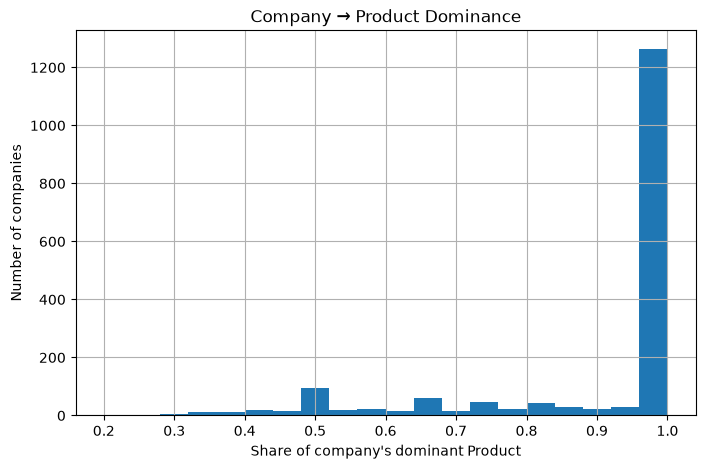

In [47]:
## Company dominance distribution
plt.figure(figsize=(8, 5))

plt.hist(
    company_dominance["Dominant_Share"],
    bins=20,
)

plt.xlabel("Share of company's dominant Product")
plt.ylabel("Number of companies")
plt.title("Company → Product Dominance")

plt.grid(True)

plt.show()

In [48]:
## Company concentration interpretation
company_dominance["Strong_Product_Association"] = (
    company_dominance["Dominant_Share"] >= 0.80
)

print(
    "Companies with >=80% dominant Product:",
    company_dominance[
        "Strong_Product_Association"
    ].sum(),
)

print(
    "Total companies:",
    len(company_dominance),
)

Companies with >=80% dominant Product: 1389
Total companies: 1751


In [49]:
## VALIDATION company coverage
train_companies = set(
    train_df[COMPANY_COL]
    .dropna()
    .astype(str)
)

val_companies = set(
    val_df[COMPANY_COL]
    .dropna()
    .astype(str)
)

unseen_val_companies = (
    val_companies - train_companies
)

seen_val_companies = (
    val_companies & train_companies
)

print(
    "Validation companies:",
    len(val_companies),
)

print(
    "Seen in training:",
    len(seen_val_companies),
)

print(
    "Unseen in training:",
    len(unseen_val_companies),
)

Validation companies: 889
Seen in training: 757
Unseen in training: 132


In [50]:
## Row level company generalization
analysis_df["Company_Seen_In_Train"] = (
    analysis_df[COMPANY_COL]
    .astype(str)
    .isin(train_companies)
)

company_generalization = (
    analysis_df
    .groupby("Company_Seen_In_Train")
    .agg(
        Rows=("Correct", "size"),
        Accuracy=("Correct", "mean"),
        Macro_F1=(
            "Actual_Product",
            lambda y: f1_score(
                y,
                analysis_df.loc[
                    y.index,
                    "Predicted_Product"
                ],
                average="macro",
                zero_division=0,
            ),
        ),
    )
)

company_generalization

,Rows,Accuracy,Macro_F1
Company_Seen_In_Train,,,
False,141,0.815603,0.559004
True,11544,0.868676,0.805821


In [51]:
## seen vs unseen company error rate
company_generalization["Error_Rate"] = (
    1 - company_generalization["Accuracy"]
)

company_generalization

,Rows,Accuracy,Macro_F1,Error_Rate
Company_Seen_In_Train,,,,
False,141,0.815603,0.559004,0.184397
True,11544,0.868676,0.805821,0.131324


In [52]:
## error rate by company
company_error_analysis = (
    analysis_df
    .groupby(COMPANY_COL)
    .agg(
        Complaints=("Correct", "size"),
        Accuracy=("Correct", "mean"),
        Mean_Confidence=(
            "Prediction_Confidence",
            "mean",
        ),
    )
)

company_error_analysis["Error_Rate"] = (
    1 - company_error_analysis["Accuracy"]
)

company_error_analysis = (
    company_error_analysis
    .sort_values(
        "Complaints",
        ascending=False,
    )
)

company_error_analysis.head(20)

,Complaints,Accuracy,Mean_Confidence,Error_Rate
Company,,,,
CAPITAL ONE FINANCIAL CORPORATION,457,0.835886,0.809002,0.164114
"CITIBANK, N.A.",456,0.879386,0.858814,0.120614
WELLS FARGO & COMPANY,450,0.831111,0.793663,0.168889
JPMORGAN CHASE & CO.,433,0.801386,0.797683,0.198614
"BANK OF AMERICA, NATIONAL ASSOCIATION",428,0.824766,0.791122,0.175234
"Block, Inc.",376,0.656915,0.694961,0.343085
ENCORE CAPITAL GROUP INC.,337,0.979228,0.969731,0.020772
Chime Financial Inc,316,0.784810,0.788415,0.215190
"Paypal Holdings, Inc",304,0.776316,0.790462,0.223684


In [53]:
## Find companies with unusually high errors
## Only inspect companies with meaningful support.

company_error_filtered = (
    company_error_analysis[
        company_error_analysis["Complaints"] >= 20
    ]
    .sort_values(
        "Error_Rate",
        ascending=False,
    )
)

company_error_filtered.head(20)

,Complaints,Accuracy,Mean_Confidence,Error_Rate
Company,,,,
Comerica,28,0.500000,0.599168,0.500000
Netspend Corporation,22,0.545455,0.625096,0.454545
OneMain Finance Corporation,45,0.644444,0.747092,0.355556
"Block, Inc.",376,0.656915,0.694961,0.343085
"Affirm Holdings, Inc",89,0.662921,0.796046,0.337079
Klarna AB,33,0.666667,0.595124,0.333333
FinCo Services Inc DBA Current,24,0.666667,0.853936,0.333333
NAVY FEDERAL CREDIT UNION,147,0.727891,0.751261,0.272109
"Credit Karma, LLC",26,0.769231,0.796398,0.230769


In [54]:
## Narrative lenth vs errors 
analysis_df["Narrative_Word_Count"] = (
    analysis_df[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

analysis_df["Narrative_Char_Count"] = (
    analysis_df[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.len()
)

analysis_df[
    [
        "Narrative_Word_Count",
        "Narrative_Char_Count",
    ]
].describe()

,Narrative_Word_Count,Narrative_Char_Count
count,11685.000000,11685.000000
mean,232.470347,1408.023278
std,237.027560,1476.028364
min,7.000000,47.000000
25%,97.000000,546.000000
50%,176.000000,1059.000000
75%,293.000000,1797.000000
max,5205.000000,31391.000000


In [55]:
## Error rate by narrative length
analysis_df["Narrative_Length_Bucket"] = pd.cut(
    analysis_df["Narrative_Word_Count"],
    bins=[
        0,
        25,
        50,
        100,
        200,
        500,
        1000,
        np.inf,
    ],
    labels=[
        "1-25",
        "26-50",
        "51-100",
        "101-200",
        "201-500",
        "501-1000",
        "1000+",
    ],
)

length_analysis = (
    analysis_df
    .groupby(
        "Narrative_Length_Bucket",
        observed=False,
    )
    .agg(
        Complaints=("Correct", "size"),
        Accuracy=("Correct", "mean"),
    )
)

length_analysis["Error_Rate"] = (
    1 - length_analysis["Accuracy"]
)

length_analysis

,Complaints,Accuracy,Error_Rate
Narrative_Length_Bucket,,,
1-25,397,0.755668,0.244332
26-50,721,0.818308,0.181692
51-100,1911,0.870225,0.129775
101-200,3544,0.884312,0.115688
201-500,4187,0.874373,0.125627
501-1000,775,0.861935,0.138065
1000+,150,0.846667,0.153333


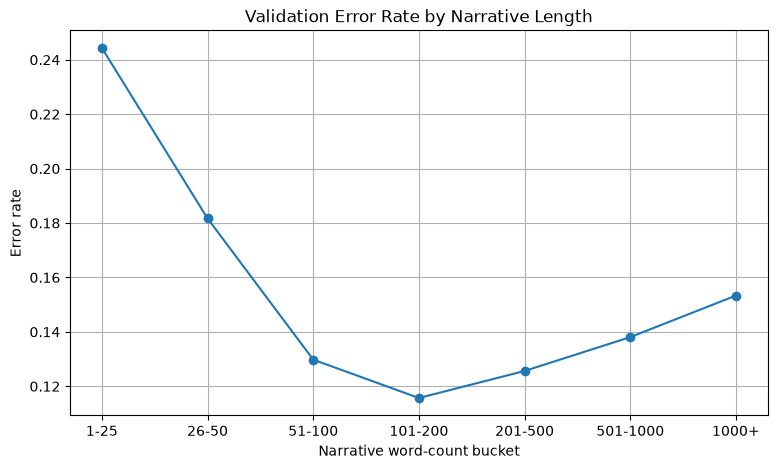

In [56]:
## Plot error rate by narrative length
plt.figure(figsize=(9, 5))

plt.plot(
    length_analysis.index.astype(str),
    length_analysis["Error_Rate"],
    marker="o",
)

plt.xlabel("Narrative word-count bucket")
plt.ylabel("Error rate")
plt.title("Validation Error Rate by Narrative Length")

plt.grid(True)

plt.show()

In [57]:
## Duplicate -group awareness
if "narrative_group" in val_df.columns:
    analysis_df["Narrative_Group"] = (
        val_df["narrative_group"]
        .values
    )

    duplicate_group_sizes = (
        analysis_df
        .groupby("Narrative_Group")
        .size()
    )

    analysis_df["Narrative_Group_Size"] = (
        analysis_df["Narrative_Group"]
        .map(duplicate_group_sizes)
    )

    duplicate_error_analysis = (
        analysis_df
        .groupby(
            analysis_df[
                "Narrative_Group_Size"
            ] > 1
        )
        .agg(
            Complaints=("Correct", "size"),
            Accuracy=("Correct", "mean"),
        )
    )

    duplicate_error_analysis["Error_Rate"] = (
        1 - duplicate_error_analysis["Accuracy"]
    )

    duplicate_error_analysis
else:
    print(
        "narrative_group not present in validation CSV. "
        "Skipping duplicate-group analysis."
    )

In [58]:
## Error concentration by actual Product
error_concentration = (
    analysis_df[
        ~analysis_df["Correct"]
    ]
    .groupby("Actual_Product")
    .size()
    .sort_values(
        ascending=False,
    )
)

error_concentration_share = (
    error_concentration
    / error_concentration.sum()
)

error_concentration_df = pd.DataFrame({
    "Errors": error_concentration,
    "Share_of_All_Errors": error_concentration_share,
})

error_concentration_df

,Errors,Share_of_All_Errors
Actual_Product,,
"Money transfer, virtual currency, or money service",283,0.183528
Checking or savings account,276,0.178988
Credit card,263,0.170558
Debt collection,244,0.158236
"Payday loan, title loan, personal loan, or advance loan",141,0.091440
Vehicle loan or lease,91,0.059014
Debt or credit management,66,0.042802
Credit reporting or other personal consumer reports,60,0.038911
Prepaid card,58,0.037613


In [59]:
## Top 3 classes' contribution to errors
top_3_error_share = (
    error_concentration_share
    .head(3)
    .sum()
)

print(
    f"Top 3 actual Product classes account for "
    f"{top_3_error_share:.2%} of all validation errors."
)

Top 3 actual Product classes account for 53.31% of all validation errors.


In [60]:
## Save error-analysis tables
class_metrics_df.to_csv(
    REPORT_DIR / "project1_error_class_metrics.csv",
    index=False,
)

confusion_pairs_df.to_csv(
    REPORT_DIR / "project1_error_confusion_pairs.csv",
    index=False,
)

error_concentration_df.to_csv(
    REPORT_DIR / "project1_error_concentration.csv",
)

company_error_analysis.to_csv(
    REPORT_DIR / "project1_company_error_analysis.csv",
)

length_analysis.to_csv(
    REPORT_DIR / "project1_narrative_length_error_analysis.csv",
)

print("Error-analysis tables saved.")

Error-analysis tables saved.


In [61]:
## Save representative high-confidence errors
high_confidence_errors[
    [
        ID_COL,
        COMPANY_COL,
        "Actual_Product",
        "Predicted_Product",
        "Prediction_Confidence",
        TEXT_COL,
    ]
].head(100).to_csv(
    REPORT_DIR
    / "project1_high_confidence_errors.csv",
    index=False,
)

print(
    "Saved high-confidence error examples."
)

Saved high-confidence error examples.


In [62]:
## Final validation metrics
final_accuracy = accuracy_score(
    y_val,
    val_predictions,
)

final_macro_f1 = f1_score(
    y_val,
    val_predictions,
    average="macro",
)

final_weighted_f1 = f1_score(
    y_val,
    val_predictions,
    average="weighted",
)

print("======================================")
print("FINAL VALIDATION METRICS")
print("======================================")

print(f"Accuracy    : {final_accuracy:.4f}")
print(f"Macro F1    : {final_macro_f1:.4f}")
print(f"Weighted F1 : {final_weighted_f1:.4f}")

FINAL VALIDATION METRICS
Accuracy    : 0.8680
Macro F1    : 0.8043
Weighted F1 : 0.8661


#### Decision Gate

In [63]:
print("======================================")
print("MODEL READINESS CHECK")
print("======================================")

print(f"Macro F1: {final_macro_f1:.4f}")
print(f"Accuracy: {final_accuracy:.4f}")

print("\nTest set status:")
print("LOCKED — NOT USED")

print("\nHyperparameter status:")
print("FROZEN — C=1.0, class_weight=None")

print("\nFeature status:")
print("FROZEN — Narrative + Company")

print("\nNext stage:")
print("Final test evaluation after error-analysis review")

MODEL READINESS CHECK
Macro F1: 0.8043
Accuracy: 0.8680

Test set status:
LOCKED — NOT USED

Hyperparameter status:
FROZEN — C=1.0, class_weight=None

Feature status:
FROZEN — Narrative + Company

Next stage:
Final test evaluation after error-analysis review


#### Analysis Insights — Error Analysis

### 1. Overall model behavior

The frozen Product Classification model achieved:

- Accuracy: 86.80%
- Macro F1: 80.43%
- Weighted F1: 86.61%

The difference between weighted F1 and Macro F1 indicates that performance
is stronger on high-support classes than on some minority classes.

---

## 2. Strong Product classes

The strongest classes include:

- Debt collection
- Mortgage
- Student loan
- Credit card
- Checking/savings

These classes appear to contain relatively strong linguistic and/or
company-level signals.

---

## 3. Weak Product classes

The weakest classes should be identified from the per-class table.

Pay particular attention to:

- Debt or credit management
- Prepaid card
- Payday loan
- Money transfer

Low recall indicates that the model frequently assigns complaints belonging
to these classes to another Product.

---

## 4. False-negative behavior

For multiclass classification, a wrong prediction has two perspectives:

Actual Product:
    The model missed this class.

Predicted Product:
    The model incorrectly attracted the complaint into this class.

Therefore, error analysis should examine both sides.

---

## 5. Main confusion pairs

The largest confusion pairs should be reported here.

Example structure:

    Money transfer → Checking
    Checking → Money transfer
    Credit card → Checking
    Checking → Credit card
    Debt collection → Credit card

These patterns indicate structured semantic overlap rather than purely random
classification errors.

---

## 6. High-confidence errors

High-confidence incorrect predictions are particularly important.

They may indicate:

- ambiguous narratives
- taxonomy overlap
- misleading language
- company-product associations
- limitations of bag-of-words representations
- possible label ambiguity

These cases should be manually inspected before attempting a more complex
model.

---

## 7. Company feature analysis

- Company produces a substantial improvement over narrative-only classification.

- However, company is high-cardinality and may encode strong Product
associations.

- The current validation therefore primarily measures performance under the
observed company distribution.

- A future robustness analysis should test performance when companies are
unseen during training.

---

## 8. Narrative length

- Compare error rate across narrative-length buckets.

- If short narratives have substantially higher error rates, limited textual
context may be an important source of uncertainty.

- If long narratives also show elevated error rates, additional text does not
necessarily guarantee better classification.

---

## 9. Duplicate/template behavior

- Exact duplicate narratives were group-aware during splitting, preventing
the same narrative group from appearing across train and validation.

- This reduces an important form of text leakage.

- Duplicate/template concentration should still be considered when interpreting
model performance.

---

## 10. Main error taxonomy

Based on the analysis, classify errors into categories such as:

1. Semantic overlap
2. Minority-class underrepresentation
3. Ambiguous narrative
4. Company-associated shortcut
5. Possible taxonomy/label ambiguity
6. Insufficient contextual information

Do not claim an error belongs to one category without evidence from
representative examples.

---

## 11. Model limitation

- The current model is a strong classical NLP baseline, but it does not
understand language semantically in the same way as transformer-based models.

- Therefore, errors involving semantically similar Product categories may
remain difficult.

---

## 12. Decision

The hyperparameter tuning stage found no justified improvement over:

    Logistic Regression
    C=1.0
    class_weight=None

Therefore the current model remains frozen.

The test set has not been used.

Next stage:

    FINAL TEST EVALUATION